Connected to Python 3.9.6

In [9]:
import sys
sys.path.append('/Users/zhaoyimin/Desktop/SCOPE Manuscipt')
import os
import scanpy as sc
from utils import compute_nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
from utils import compute_nn
from branchpoint_localization import trace_to_highest_density_point
import pickle
import random
random.seed(2025)

os.chdir('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance')
data = sc.read_h5ad('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/data_complete_results_clone.h5ad')

with open('/Users/zhaoyimin/Desktop/SCOPE Manuscipt/Figure3 Larry/res variable importance/conformal_result.pkl', 'rb') as file:
    conformal_result = pickle.load(file)

In [10]:
data

AnnData object with n_obs × n_vars = 129929 × 3340
    obs: 'n_counts', 'Time_Point', 'Source', 'Well', 'mito_frac', 'time_info', 'state_info', 'precomputed_fate_bias', 'selected_clonal_cells', 'Gata1_states', 'palantir_pseudotime', 'palantir_entropy', 'mellon_log_density', 'mellon_log_density_clipped', 'visit', 'iteration_recruited', 'clone_id'
    var: 'highly_variable'
    uns: 'DM_EigenValues', 'Time_Point_colors', 'clonal_time_points', 'data_des', 'max_mito', 'min_tot', 'neighbors', 'palantir_waypoints', 'state_info_colors', 'time_info_colors', 'time_ordering', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_clone', 'X_emb', 'X_pca', 'X_umap', 'dummy_label', 'palantir_fate_probabilities'
    varm: 'feature_importance_hvg_iter_0', 'feature_importance_hvg_iter_1', 'feature_importance_hvg_iter_10', 'feature_importance_hvg_iter_100', 'feature_importance_hvg_iter_101', 'feature_importance_hvg_iter_102', 'feature_importance_hvg_iter_103', 'feature_importance_hvg_it

In [11]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [12]:
prediction_set = pd.DataFrame(conformal_result['prediction_set'])
#calculate barcode for cells to be recruited 
terminal_state_celltype = ['Monocyte', 'Neutrophil', 'Baso', 'Mast', 'Erythroid', 'Meg', 'Eos', 'Ccr7_DC']
day6_terminal_barcode = data[(data.obs['Time_Point'] == '6.0' ) & (data.obs['state_info'].isin(terminal_state_celltype))].obs_names.tolist()
cells2recruit_barcode = data.obs_names[~data.obs_names.isin(day6_terminal_barcode)].tolist()


### 1 Branchpoint-Meg-Ery: Visulize the branchpoint

#### 1.1 Find branchpoint

In [13]:
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Meg'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Erythroid'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Meg', 'Erythroid'})
]


# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_meg_ery = prediction_set[combined_condition].index

#subset dataset
data_subset_meg_ery = data[barcode_meg_ery]

#calculate KNN graph
distance, indices = compute_nn(data_subset_meg_ery.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_meg_ery.obs['mellon_log_density'].to_list()


# Step 1: Create label list and index mapping
unique_labels = ['Meg', 'Erythroid']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_meg_ery.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_meg_ery].iloc[:,0]):
    for label in label_set:
        label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])


clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_meg_ery.obsm['X_pca'].shape[0]):
    #if i not in visited:
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]


meg_ery_counts = []

for center, points in clusters.items():
    barcode = barcode_meg_ery[points]
    #cover_meg = data_subset[barcode].obs['cover_Meg'].to_numpy()
    #cover_ery = data_subset[barcode].obs['cover_Erythroid'].to_numpy()
    #num_meg_ery = ((cover_meg == 1) & (cover_ery == 1)).sum()
    num_meg_ery = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Meg', 'Erythroid'})))
    meg_ery_counts.append((center, num_meg_ery))

# Step 2: Sort clusters by number of Meg+Ery cells (descending)
top_clusters = sorted(meg_ery_counts, key=lambda x: x[1], reverse=True)[:5]

# Step 3: Collect barcodes for top 5 clusters
barcode_branchpoint_top5 = []

for center, _ in top_clusters:
    barcodes = barcode_meg_ery[clusters[center]]
    barcode_branchpoint_top5.append(barcodes)

# Step 5: Save the largest one separately
largest_center = top_clusters[0][0]
barcode_branchpoint_meg_ery = barcode_meg_ery[clusters[largest_center]]


###plot branchpoint Meg and Ery

df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['state_info'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint_meg_ery, 'Labels'] = 'Branchpoint'

#save barcode_branchpoint_meg_ery
with open('barcode_branchpoint_meg_ery.pkl', 'wb') as file:
    pickle.dump(barcode_branchpoint_meg_ery, file)

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_23699/4168815323.py:73: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_meg_ery = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Meg', 'Erythroid'})))


#### 1.2 Plot branchpoint

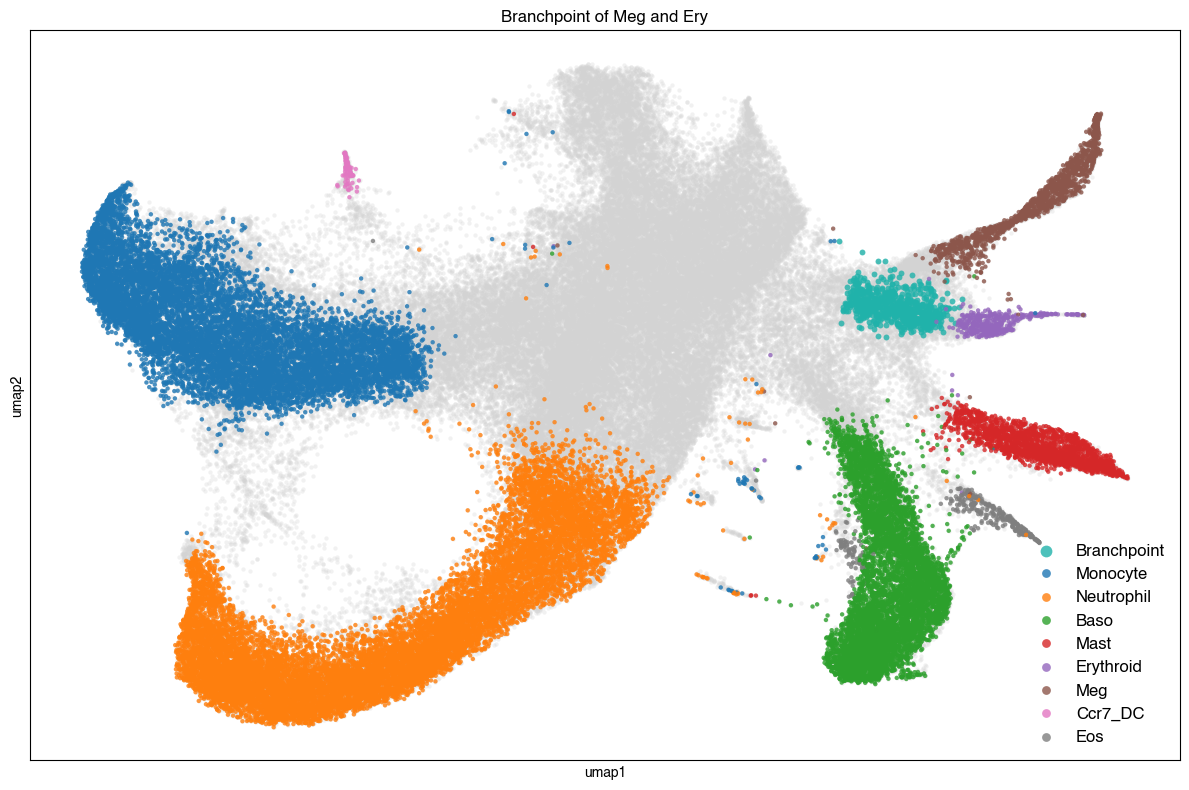

In [5]:
#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(12, 8))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']
"""
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#20B2AA', edgecolor='black', linewidth=0.2, s=15, label='Branchpoint'
)
"""
sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#20B2AA',  s=18, linewidth=0, alpha=0.8, edgecolor='black',  label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=12, frameon=False)
plt.title('Branchpoint of Meg and Ery')
plt.xlabel('umap1')
plt.ylabel('umap2')
plt.xticks([])
plt.yticks([])
plt.tight_layout()

#### 1.3 Slope for linear model: entropy ~ pseudotime

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Coefficient (slope): -14.5601
Intercept: 1.7415


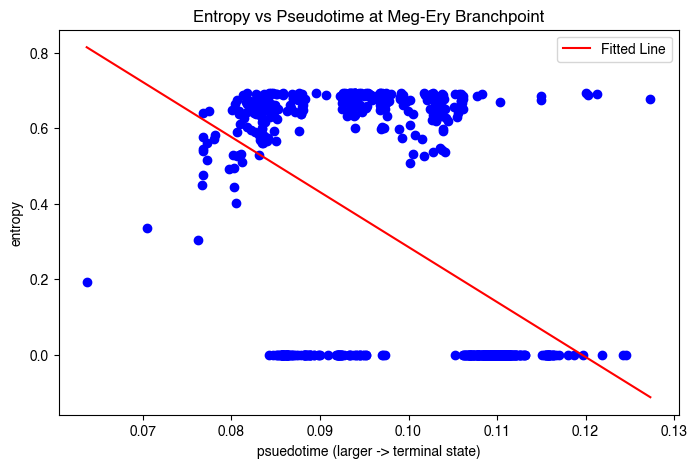

In [48]:
from scipy.stats import entropy
data_branchpoint = data[barcode_branchpoint_meg_ery]

branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)

df_pseudotime_entropy = pd.DataFrame({'pseudotime':branchpoint_pseudotime, 'entropy': branchpoint_entropy})


#pseudotime 1 will be terminal state
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Fit linear regression
model = LinearRegression()
model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())

# Report coefficients
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Predict y values for plotting
x_vals = np.linspace(df_pseudotime_entropy['pseudotime'].min(), df_pseudotime_entropy['pseudotime'].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_vals)
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_pseudotime_entropy['pseudotime'], df_pseudotime_entropy['entropy'], color='blue')
plt.plot(x_vals, y_pred, color='red', label='Fitted Line')
plt.xlabel('psuedotime (larger -> terminal state)')
plt.ylabel('entropy')
plt.title('Entropy vs Pseudotime at Meg-Ery Branchpoint')
plt.legend()
#plt.show()
plt.savefig('./appendix plot/lm_meg_ery_pseudotime_entropy.pdf', dpi = 300)

slope = model.coef_[0]

#### 1.4 Plot distribution of slopes

In [12]:
#subsample inside the region
sample_size = len(barcode_branchpoint_meg_ery)
res = []
n_trial = 500
for i in range(n_trial):
    sample_barocdoe = np.random.choice(barcode_meg_ery, size=sample_size, replace=False)
    data_branchpoint = data[sample_barocdoe]
    branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
    branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
    branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)
    model = LinearRegression()
    model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())
    res.append(model.coef_[0])

#calculate p value
p = 0
for i in res:
    if i < slope:
        p += 1 / n_trial 
print(p)

0


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


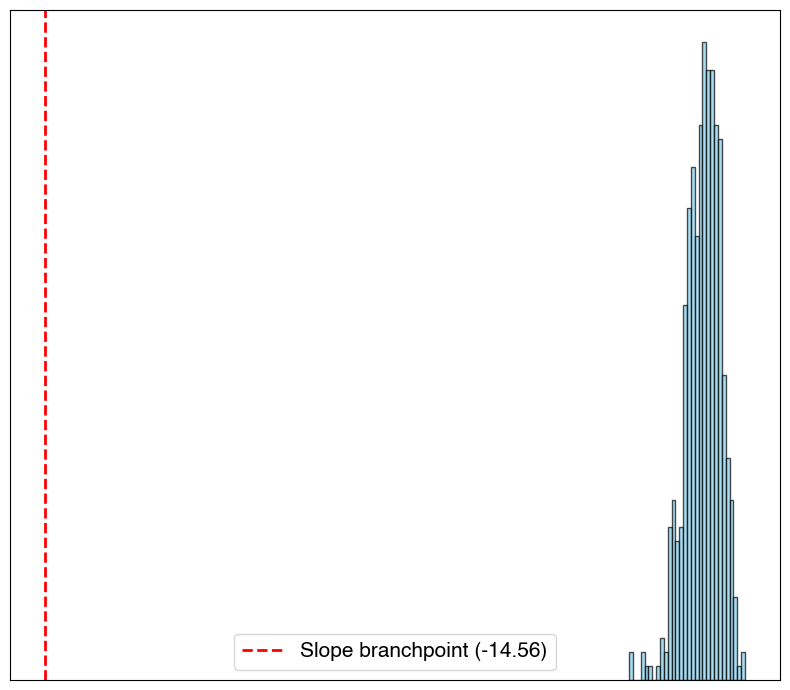

In [18]:
import matplotlib.pyplot as plt

# res is your vector (e.g., list, NumPy array, or pandas Series)
plt.figure(figsize=(8, 7))

# Plot histogram
plt.hist(res, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical line (remove fontsize parameter)
plt.axvline(x=-2.56, color='red', linestyle='--', linewidth=2, label='Slope branchpoint (-14.56)')

# Add labels and legend
plt.xlabel('')
plt.ylabel('')
plt.title('')
plt.xticks([])
plt.yticks([])
plt.legend(fontsize=15)  # Move fontsize to legend

plt.tight_layout()
plt.savefig('./vector plot/slope_naive_sampling.pdf')

#### 1.5 TF importance for Ery Lineage

In [ ]:
# Calculate weighted variable importance specifically for Ery lineage
unique_iterations = set(data[barcode_branchpoint_meg_ery].obs['iteration_recruited'])
#print(f"Unique iterations: {sorted(unique_iterations)}")

# Calculate proportion of cells for each iteration (weights)
iteration_counts = data[barcode_branchpoint_meg_ery].obs['iteration_recruited'].value_counts()
total_cells = len(barcode_branchpoint_meg_ery)
iteration_weights = iteration_counts / total_cells

# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Ery lineage specifically (only for HVGs)
weighted_importance_ery = np.zeros(hvg_mask.sum())

# Calculate weighted sum across all iterations for Ery column
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Get variable importance for this iteration
        importance = data.varm[feature_importance_key]
        # Filter to HVGs and extract Ery column specifically
        importance_hvg = importance[hvg_mask]
        weight = iteration_weights[iter_id]
        weighted_importance_ery += weight * importance_hvg['Erythroid'].values
        #print(f"Added iteration {iter_id} (Ery) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Create DataFrame with Ery-specific results (using only HVG gene names)
importance_ery_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_ery': weighted_importance_ery
})

# Sort by Ery importance
importance_ery_df = importance_ery_df.sort_values('weighted_importance_ery', ascending=False)
print(f"\nTop 20 most important features for Ery lineage (HVGs only):")
print(importance_ery_df.head(20))

importance_ery_df.to_csv('./larry_variable_importance_ery.csv', index=False)


Top 20 most important features for Ery lineage (HVGs only):
           gene  weighted_importance_ery
1673     Hbb-bt                 0.048256
560        Car2                 0.043728
1682       Hdgf                 0.026060
1672     Hbb-bs                 0.023635
974         Emb                 0.022410
1565       Gmpr                 0.021227
2522      Podxl                 0.020684
2590     Ptp4a3                 0.017703
474      Bcl11a                 0.014378
2776  Serpinb1a                 0.013865
485        Bex4                 0.013267
3147       Tph1                 0.013239
3052       Tfrc                 0.013080
1633      Gstm1                 0.012696
2160      Muc13                 0.012431
676       Cebpb                 0.011105
363       Anxa2                 0.010869
1671     Hba-a2                 0.010827
2929      Spns2                 0.010474
2639      Rbms1                 0.010464


In [29]:
# Calculate weighted variable importance specifically for Ery lineage
unique_iterations = set(data[barcode_branchpoint_meg_ery].obs['iteration_recruited'])
#print(f"Unique iterations: {sorted(unique_iterations)}")

# Calculate proportion of cells for each iteration (weights)
iteration_counts = data[barcode_branchpoint_meg_ery].obs['iteration_recruited'].value_counts()
total_cells = len(barcode_branchpoint_meg_ery)
iteration_weights = iteration_counts / total_cells

# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Ery lineage specifically (only for HVGs)
weighted_importance_Meg = np.zeros(hvg_mask.sum())

# Calculate weighted sum across all iterations for Ery column
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Get variable importance for this iteration
        importance = data.varm[feature_importance_key]
        # Filter to HVGs and extract Ery column specifically
        importance_hvg = importance[hvg_mask]
        weight = iteration_weights[iter_id]
        weighted_importance_Meg += weight * importance_hvg['Meg'].values
        #print(f"Added iteration {iter_id} (Ery) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Create DataFrame with Ery-specific results (using only HVG gene names)
importance_Meg_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_Meg': weighted_importance_Meg
})

# Sort by Ery importance
importance_Meg_df = importance_Meg_df.sort_values('weighted_importance_Meg', ascending=False)
print(f"\nTop 20 most important features for Meg lineage (HVGs only):")
print(importance_Meg_df.head(20))

importance_Meg_df.to_csv('./larry_variable_importance_Meg.csv', index=False)


Top 20 most important features for Meg lineage (HVGs only):
          gene  weighted_importance_Meg
2460       Pf4                 0.053582
2621     Rap1b                 0.030920
2529      Ppbp                 0.025537
2255      Nrgn                 0.025457
2147     Mrvi1                 0.022183
1873     Itgb3                 0.020382
1865    Itga2b                 0.020247
974        Emb                 0.018880
2857    Slc6a4                 0.017298
2812   Slc14a1                 0.016795
2783  Serpine2                 0.014466
2615  Rabgap1l                 0.014217
970       Ehd3                 0.013384
2408     Parvb                 0.013004
2639     Rbms1                 0.012697
1023       F2r                 0.012360
2644    Rbpms2                 0.011764
1989    Lgalsl                 0.011488
1984    Lgals1                 0.011205
2604    Rab27b                 0.010818


##### check the rank of 2 important TFs(GATA1, GATA2) Manu mentioned

In [54]:
# Check ranks of GATA1 and GATA2 in Ery importance ranking
# Reset index to get proper ranking after sorting
importance_ery_df_ranked = importance_ery_df.reset_index(drop=True)

genes_to_check = ['Gata1', 'Gata2']

print("Important TF rankings in Ery-specific importance:")
print("-" * 50)

print(f"\nTotal number of genes: {np.sum(data.var['highly_variable'])}")
for gene in genes_to_check:
    if gene in importance_ery_df_ranked['gene'].values:
        # Find the position in the sorted DataFrame (0-indexed, so add 1 for rank)
        gene_position = importance_ery_df_ranked[importance_ery_df_ranked['gene'] == gene].index[0]
        rank = gene_position + 1
        importance_score = importance_ery_df_ranked[importance_ery_df_ranked['gene'] == gene]['weighted_importance_ery'].values[0]
        print(f"{gene}: Rank {rank}, Ery Importance: {importance_score:.6f}")
        print(f"{gene}: Quantile: {rank / np.sum(data.var['highly_variable']):.4f}")
    else:
        print(f"{gene}: Not found in dataset")

Important TF rankings in Ery-specific importance:
--------------------------------------------------

Total number of genes: 3340
Gata1: Not found in dataset
Gata2: Rank 129, Ery Importance: 0.001528
Gata2: Quantile: 0.0386


### 2 Branchpoint-Mono-Neu: Visulize the branchpoint

#### 2.1 Find the branchpoint 

In [14]:
conditions = [
    prediction_set['prediction_set'].apply(lambda x: x == {'Monocyte'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Neutrophil'}),
    prediction_set['prediction_set'].apply(lambda x: x == {'Neutrophil','Monocyte'} or x == {'Monocyte','Neutrophil'})
]

# Combine with OR
combined_condition = conditions[0] | conditions[1] | conditions[2]

# Filter the DataFrame
barcode_mono_neu = prediction_set[combined_condition].index

#subset dataset
data_subset_mono_neu = data[barcode_mono_neu]

#calculate KNN graph
distance, indices = compute_nn(data_subset_mono_neu.obsm['X_pca'], 30)

#do density clustering in new KNN graph
density = data_subset_mono_neu.obs['mellon_log_density'].to_list()


# Step 1: Create label list and index mapping
unique_labels = ['Monocyte', 'Neutrophil']
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
n_labels = len(unique_labels)
n_cells = data_subset_mono_neu.n_obs

# Step 2: Convert prediction_set to binary label matrix
label_matrix = np.zeros((n_cells, n_labels), dtype=bool)
for i, label_set in enumerate(prediction_set.loc[barcode_mono_neu].iloc[:,0]):
    for label in label_set:
        label_matrix[i, label_to_idx[label]] = True

# Step 3: Efficiently filter KNN graph
filtered_indices = []
filtered_distances = []

for i in range(n_cells):
    i_vec = label_matrix[i]  # shape: (n_labels,)
    neighbor_idxs = indices[i]  # original neighbors (shape: (k,))
    
    neighbor_vecs = label_matrix[neighbor_idxs]  # shape: (k, n_labels)
    
    # Subset condition: i's label vector <= neighbor's label vector
    valid_mask = np.all(i_vec <= neighbor_vecs, axis=1)

    # Apply mask
    filtered_indices.append(neighbor_idxs[valid_mask])
    filtered_distances.append(distance[i][valid_mask])

clusters = {}

#for each cell, determine the cluster center 
for i in range(data_subset_mono_neu.obsm['X_pca'].shape[0]):
    #if i not in visited:
    center = trace_to_highest_density_point(i, filtered_indices, density)
    if center in clusters:
        clusters[center].append(i)
    else:
        clusters[center] = [i]


mono_neu_counts = []

for center, points in clusters.items():
    barcode = barcode_mono_neu[points]
    num_mono_neu = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Monocyte', 'Neutrophil'} )))
    mono_neu_counts.append((center, num_mono_neu))


# Step 2: Sort clusters by number of Meg+Ery cells (descending)
top_clusters = sorted(mono_neu_counts, key=lambda x: x[1], reverse=True)[:5]

# Step 3: Collect barcodes for top 5 clusters
barcode_branchpoint_top5 = []

for center, _ in top_clusters:
    barcodes = barcode_mono_neu[clusters[center]]
    barcode_branchpoint_top5.append(barcodes)

# Step 5: Save the largest one separately
largest_center = top_clusters[0][0]
barcode_branchpoint_mono_neu = barcode_mono_neu[clusters[largest_center]]

with open('barcode_branchpoint_mono_neu.pkl', 'wb') as file:
    pickle.dump(barcode_branchpoint_mono_neu, file)

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/var/folders/2f/04q3w5f15yj7jtfv7s2n6b2w0000gn/T/ipykernel_23699/2836010350.py:68: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_mono_neu = int(np.sum(prediction_set.loc[barcode].apply(lambda x: x == {'Monocyte', 'Neutrophil'} )))


#### 2.2 Plot branchpoint

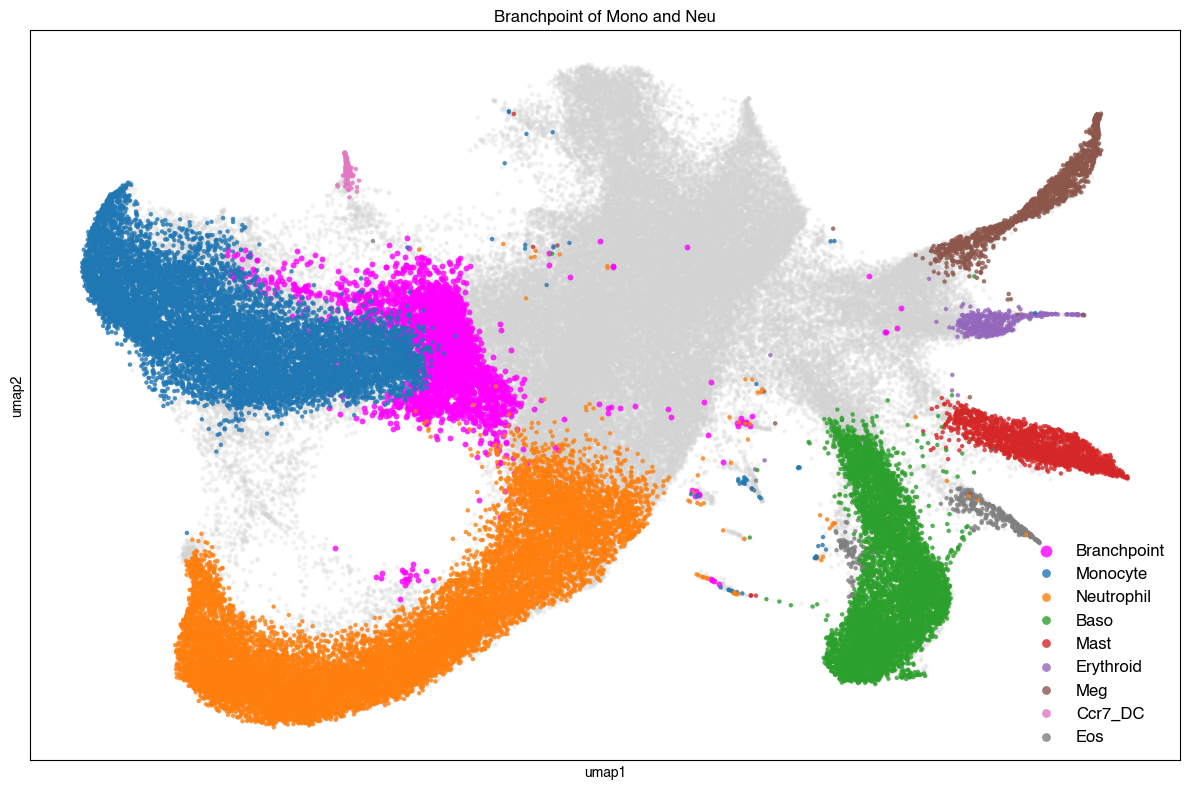

In [40]:
df = pd.DataFrame({'umap1': data.obsm['X_umap'][:, 0], 'umap2': data.obsm['X_umap'][:, 1], 'Labels':data.obs['state_info'].tolist()})
df.index = data.obs_names
df.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df.loc[barcode_branchpoint_mono_neu, 'Labels'] = 'Branchpoint'


#plot branchpoint in umap embedding
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(12, 8))

# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
    )

# Plot special label = 1 in red (highlighted fate)
df_highlight = df[df['Labels'] == 'Branchpoint']

sns.scatterplot(
    x='umap1', y='umap2', data=df_highlight,
    color='#FF00FF',  s=18, linewidth=0, alpha=0.8, edgecolor='black',  label='Branchpoint'
)

# Optionally: plot other label values (e.g., cell types) using `hue`
df_other = df[~df.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower right', markerscale=2.0,  fontsize=12, frameon=False)
plt.title('Branchpoint of Mono and Neu')
plt.xlabel('umap1')
plt.ylabel('umap2')
plt.xticks([])
plt.yticks([])
plt.tight_layout()

#### 2.3 Slope for linear model: entropy ~ pseudotime

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Coefficient (slope): -2.4057
Intercept: 0.4639


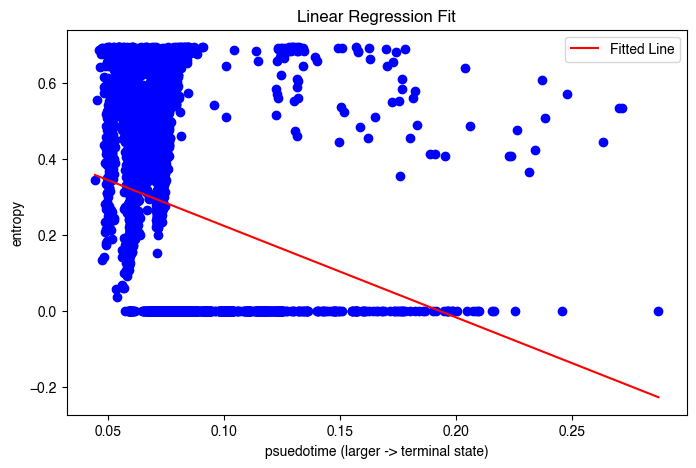

In [41]:
from scipy.stats import entropy
data_branchpoint = data[barcode_branchpoint_mono_neu]

branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)

df_pseudotime_entropy = pd.DataFrame({'pseudotime':branchpoint_pseudotime, 'entropy': branchpoint_entropy})


#pseudotime 1 will be terminal state
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Fit linear regression
model = LinearRegression()
model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())

# Report coefficients
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

# Predict y values for plotting
x_vals = np.linspace(df_pseudotime_entropy['pseudotime'].min(), df_pseudotime_entropy['pseudotime'].max(), 100).reshape(-1, 1)
y_pred = model.predict(x_vals)
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_pseudotime_entropy['pseudotime'], df_pseudotime_entropy['entropy'], color='blue')
plt.plot(x_vals, y_pred, color='red', label='Fitted Line')
plt.xlabel('psuedotime (larger -> terminal state)')
plt.ylabel('entropy')
plt.title('Linear Regression Fit')
plt.legend()
plt.savefig('./appendix plot/lm_mono_neu_pseudotime_entropy.pdf', dpi = 300)
#plt.show()

slope = model.coef_[0]

#### 2.4 Plot distribution of slopes

In [42]:
#subsample inside the region
sample_size = len(barcode_branchpoint_mono_neu)
res = []
n_trial = 500
for i in range(n_trial):
    sample_barocdoe = np.random.choice(barcode_mono_neu, size=sample_size, replace=False)
    data_branchpoint = data[sample_barocdoe]
    branchpoint_pseudotime = data_branchpoint.obs['palantir_pseudotime']
    branchpoint_fate_bias = data_branchpoint.obsm['dummy_label']
    branchpoint_entropy = branchpoint_fate_bias.apply(lambda x: entropy(x), axis=1)
    model = LinearRegression()
    model.fit(branchpoint_pseudotime.to_numpy().reshape(-1, 1), branchpoint_entropy.to_numpy())
    res.append(model.coef_[0])

#calculate p value
p = 0
for i in res:
    if i < slope:
        p += 1 / n_trial 
print(p)

0


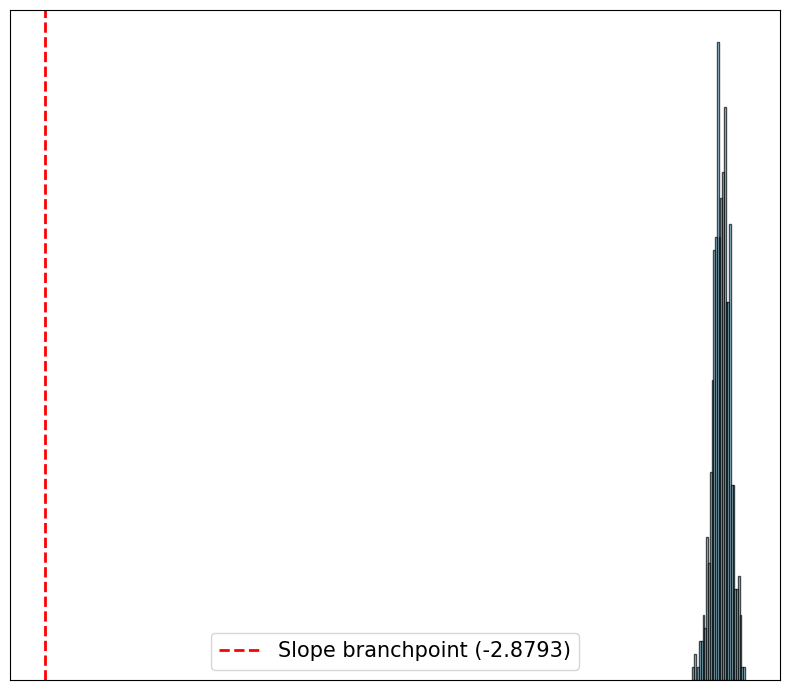

In [ ]:
import matplotlib.pyplot as plt

# res is your vector (e.g., list, NumPy array, or pandas Series)
plt.figure(figsize=(8, 7))

# Plot histogram
plt.hist(res, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical line (remove fontsize parameter)
plt.axvline(x=-2.8793, color='red', linestyle='--', linewidth=2, label='Slope branchpoint (-2.4057)')

# Add labels and legend
plt.xlabel('')
plt.ylabel('')
plt.title('')
plt.xticks([])
plt.yticks([])
plt.legend(fontsize=15)  # Move fontsize to legend

plt.tight_layout()
plt.savefig('./appendix plot/distribution_slopes_mono_neu.png', dpi=300)

#### 2.5 variable importance for Monocyte and Neutrophil

In [49]:
# Calculate weighted variable importance specifically for Monocyte lineage

# Get all unique iterations among recruited cells in the mono/neu branch
unique_iterations = set(data[barcode_branchpoint_mono_neu].obs['iteration_recruited'])
# print(f"Unique iterations: {sorted(unique_iterations)}")

# Calculate proportion (weight) of cells from each iteration
iteration_counts = data[barcode_branchpoint_mono_neu].obs['iteration_recruited'].value_counts()
total_cells = len(barcode_branchpoint_mono_neu)
iteration_weights = iteration_counts / total_cells

# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Monocyte lineage (only HVGs)
weighted_importance_mono = np.zeros(hvg_mask.sum())

# Loop over iterations and accumulate weighted importance for Monocyte
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Pull variable importance for this iteration
        importance = data.varm[feature_importance_key]

        # Restrict to HVGs
        importance_hvg = importance[hvg_mask]

        # Get the iteration weight
        weight = iteration_weights[iter_id]

        # Add weighted Monocyte importance
        weighted_importance_mono += weight * importance_hvg['Monocyte'].values

        # print(f"Added iteration {iter_id} (Monocyte) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Build results DataFrame for Monocyte (HVG genes only)
importance_mono_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_monocyte': weighted_importance_mono
})

# Sort descending by Monocyte importance
importance_mono_df = importance_mono_df.sort_values('weighted_importance_monocyte', ascending=False)

print("\nTop 20 most important features for Monocyte lineage (HVGs only):")
print(importance_mono_df.head(20))

# Save
importance_mono_df.to_csv('./larry_variable_importance_monocyte.csv', index=False)


Top 20 most important features for Monocyte lineage (HVGs only):
        gene  weighted_importance_monocyte
2122    Mmp8                      0.038657
814     Ctsc                      0.033502
3272  Wfdc17                      0.031162
2009     Lpl                      0.030876
821     Ctss                      0.030086
2577    Psap                      0.028321
2153  Ms4a6d                      0.026854
1033   Fabp5                      0.023507
3055   Tgfbi                      0.022702
2717  S100a4                      0.022649
2152  Ms4a6c                      0.022180
2280   Olfm1                      0.019408
3253    Vcan                      0.016649
2141    Mrc1                      0.016626
736   Clec4n                      0.016360
869     Dab2                      0.016239
2221     Ngp                      0.013131
605     Ccr2                      0.012799
795    Csf1r                      0.011699
313    Ahnak                      0.011668


In [53]:
# Check ranks of CEBPA and SPI1 in Monocyte importance ranking

# Reset index after sorting so rank = row index + 1
importance_mono_df_ranked = importance_mono_df.reset_index(drop=True)

genes_to_check = ['Cebpa', 'Spi1']

print("Important TF rankings in Monocyte-specific importance:")
print("-" * 50)

# total number of HVGs (denominator for quantile)
total_hvgs = np.sum(data.var['highly_variable'])
print(f"\nTotal number of genes: {total_hvgs}")

for gene in genes_to_check:
    if gene in importance_mono_df_ranked['gene'].values:
        # get 0-based index, then convert to rank starting at 1
        gene_position = importance_mono_df_ranked[
            importance_mono_df_ranked['gene'] == gene
        ].index[0]
        rank = gene_position + 1

        importance_score = importance_mono_df_ranked.loc[
            gene_position, 'weighted_importance_monocyte'
        ]

        quantile = rank / total_hvgs

        print(f"{gene}: Rank {rank}, Monocyte Importance: {importance_score:.6f}")
        print(f"{gene}: Quantile: {quantile:.4f}")
    else:
        print(f"{gene}: Not found in dataset")


Important TF rankings in Monocyte-specific importance:
--------------------------------------------------

Total number of genes: 3340
Cebpa: Not found in dataset
Spi1: Not found in dataset


In [50]:
# Calculate weighted variable importance specifically for Neutrophil lineage

# Get all unique iterations among recruited cells in the mono/neutrophil branch
unique_iterations = set(data[barcode_branchpoint_mono_neu].obs['iteration_recruited'])
# print(f"Unique iterations: {sorted(unique_iterations)}")

# Calculate proportion (weight) of cells from each iteration
iteration_counts = data[barcode_branchpoint_mono_neu].obs['iteration_recruited'].value_counts()
total_cells = len(barcode_branchpoint_mono_neu)
iteration_weights = iteration_counts / total_cells

# Get HVG mask
hvg_mask = data.var['highly_variable']

# Initialize weighted sum for Neutrophil lineage (only HVGs)
weighted_importance_neu = np.zeros(hvg_mask.sum())

# Loop over iterations and accumulate weighted importance for Neutrophil
for iter_id in unique_iterations:
    feature_importance_key = f'feature_importance_hvg_iter_{iter_id}'
    if feature_importance_key in data.varm.keys():
        # Pull variable importance for this iteration
        importance = data.varm[feature_importance_key]

        # Restrict to HVGs
        importance_hvg = importance[hvg_mask]

        # Get the iteration weight
        weight = iteration_weights[iter_id]

        # Add weighted Neutrophil importance
        weighted_importance_neu += weight * importance_hvg['Neutrophil'].values

        # print(f"Added iteration {iter_id} (Neutrophil) with weight {weight:.4f}")
    else:
        print(f"Warning: {feature_importance_key} not found in data.varm")

# Build results DataFrame for Neutrophil (HVG genes only)
importance_neu_df = pd.DataFrame({
    'gene': data.var_names[hvg_mask],
    'weighted_importance_neutrophil': weighted_importance_neu
})

# Sort descending by Neutrophil importance
importance_neu_df = importance_neu_df.sort_values('weighted_importance_neutrophil', ascending=False)

print("\nTop 20 most important features for Neutrophil lineage (HVGs only):")
print(importance_neu_df.head(20))

# Save
importance_neu_df.to_csv('./larry_variable_importance_neutrophil.csv', index=False)



Top 20 most important features for Neutrophil lineage (HVGs only):
         gene  weighted_importance_neutrophil
2221      Ngp                        0.041812
1633    Gstm1                        0.021437
934      Dstn                        0.020383
1872   Itgb2l                        0.017966
1154    Gata2                        0.016556
814      Ctsc                        0.016493
554      Camp                        0.015464
972     Elane                        0.014790
1984   Lgals1                        0.014398
700     Chil3                        0.014303
3150     Tpm4                        0.013963
2548    Prdx5                        0.013545
798   Csf2rb2                        0.013534
1138     G0s2                        0.013390
2101    Mgst2                        0.012817
797    Csf2rb                        0.012415
770      Cpa3                        0.011932
1077     Fcnb                        0.011360
313     Ahnak                        0.011148
1023      F2

### 3 Plot 2 branchpoints in single plot

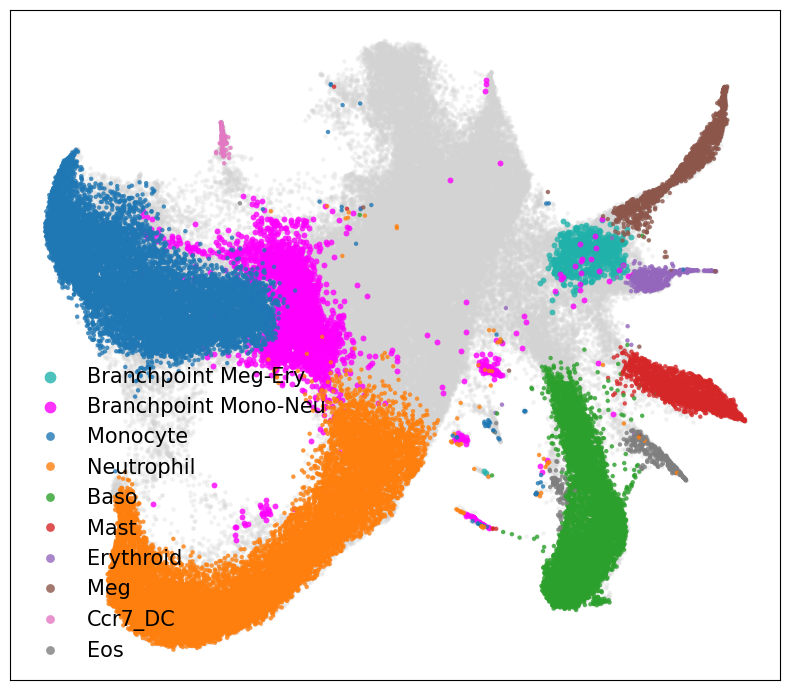

In [33]:
plt.figure(figsize=(8, 7))
# Combined plot with both branchpoints
df_combined = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0], 
    'umap2': data.obsm['X_umap'][:, 1], 
    'Labels': data.obs['state_info'].tolist()
})
df_combined.index = data.obs_names
df_combined.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df_combined.loc[barcode_branchpoint_meg_ery, 'Labels'] = 'Branchpoint_Meg_Ery'
df_combined.loc[barcode_branchpoint_mono_neu, 'Labels'] = 'Branchpoint_Mono_Neu'


# Plot all points in light grey as a base
sns.scatterplot(
    x='umap1', y='umap2', data=df_combined,
    color='lightgrey', edgecolor=None, s=10, linewidth=0, alpha=0.3, legend=False
)

# Plot Meg-Ery branchpoint
df_meg_ery = df_combined[df_combined['Labels'] == 'Branchpoint_Meg_Ery']
sns.scatterplot(
    x='umap1', y='umap2', data=df_meg_ery,
    color='#20B2AA', s=18, linewidth=0, alpha=0.8, edgecolor='black', 
    label='Branchpoint Meg-Ery'
)

# Plot Mono-Neu branchpoint
df_mono_neu = df_combined[df_combined['Labels'] == 'Branchpoint_Mono_Neu']
sns.scatterplot(
    x='umap1', y='umap2', data=df_mono_neu,
    color='#FF00FF', s=18, linewidth=0, alpha=0.8, edgecolor='black', 
    label='Branchpoint Mono-Neu'
)

# Plot other cell types
df_other = df_combined[~df_combined.index.isin(cells2recruit_barcode)]
if not df_other.empty:
    # Filter out the branchpoints from other cell types to avoid duplication
    df_other = df_other[~df_other['Labels'].str.contains('Branchpoint')]
    sns.scatterplot(
        x='umap1', y='umap2', data=df_other,
        hue='Labels', palette='tab10', s=10, linewidth=0, alpha=0.8, legend='brief'
    )

# Clean up and finalize
plt.legend(loc='lower left', markerscale=2.0, fontsize=15, frameon=False)
plt.title('') #Branchpoints: Meg-Ery and Mono-Neu
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('./Figure3 Larry/2_branchpoints.png', dpi=300)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 0. Illustrator-friendly font setup
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# 1. Build combined dataframe
df_combined = pd.DataFrame({
    'umap1': data.obsm['X_umap'][:, 0],
    'umap2': data.obsm['X_umap'][:, 1],
    'Labels': data.obs['state_info'].tolist()
}, index=data.obs_names)

df_combined.loc[cells2recruit_barcode, 'Labels'] = 'TBD'
df_combined.loc[barcode_branchpoint_meg_ery, 'Labels'] = 'Branchpoint_Meg_Ery'
df_combined.loc[barcode_branchpoint_mono_neu, 'Labels'] = 'Branchpoint_Mono_Neu'

# Separate dataframes
df_meg_ery = df_combined[df_combined['Labels'] == 'Branchpoint_Meg_Ery']
df_mono_neu = df_combined[df_combined['Labels'] == 'Branchpoint_Mono_Neu']

# “Other” cell types (exclude TBD + branchpoints)
df_other = df_combined[
    (~df_combined.index.isin(cells2recruit_barcode)) &
    (~df_combined['Labels'].str.contains('Branchpoint')) &
    (df_combined['Labels'] != 'TBD')
].copy()

# 2. Create stable color map (keep your original palette)
other_labels_in_order = pd.unique(df_other['Labels'])
tab_colors = sns.color_palette("tab10", n_colors=len(other_labels_in_order))
label_to_color = {
    lab: tab_colors[i] for i, lab in enumerate(other_labels_in_order)
}
label_to_color['Branchpoint_Meg_Ery'] = '#20B2AA'
label_to_color['Branchpoint_Mono_Neu'] = '#FF00FF'

# 3. MAIN PANEL (no legend, rasterized for Illustrator)
fig_main, ax = plt.subplots(figsize=(8, 7))

# Base layer: all points in light grey
ax.scatter(
    df_combined['umap1'], df_combined['umap2'],
    c='lightgrey', s=10, alpha=0.3, linewidth=0, rasterized=True
)

# Branchpoints
if len(df_meg_ery) > 0:
    ax.scatter(
        df_meg_ery['umap1'], df_meg_ery['umap2'],
        c=[label_to_color['Branchpoint_Meg_Ery']], s=18, alpha=0.8,
        linewidth=0, rasterized=True
    )

if len(df_mono_neu) > 0:
    ax.scatter(
        df_mono_neu['umap1'], df_mono_neu['umap2'],
        c=[label_to_color['Branchpoint_Mono_Neu']], s=18, alpha=0.8,
        linewidth=0, rasterized=True
    )

# Other cell types
for lab in other_labels_in_order:
    sub = df_other[df_other['Labels'] == lab]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['umap1'], sub['umap2'],
        c=[label_to_color[lab]], s=10, alpha=0.8,
        linewidth=0, rasterized=True
    )

# Clean axes
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(''); ax.set_ylabel(''); ax.set_title('')
fig_main.tight_layout()

# Save main panel (no legend)
fig_main.savefig(
    './vector plot/2_branchpoints_main.pdf',
    dpi=300, bbox_inches='tight'
)
plt.close(fig_main)

# 4. LEGEND PANEL (vector, matching colors)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Fixed branchpoint colors (same as your plot)
label_to_color = {
    'Branchpoint_Meg_Ery': '#20B2AA',   # teal
    'Branchpoint_Mono_Neu': '#FF00FF'   # magenta
}

# Create legend handles
handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=label_to_color['Branchpoint_Meg_Ery'],
           markeredgecolor='none', markersize=8,
           label='Branchpoint Meg-Ery'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=label_to_color['Branchpoint_Mono_Neu'],
           markeredgecolor='none', markersize=8,
           label='Branchpoint Mono-Neu')
]

# Create transparent legend figure
fig_leg, ax_leg = plt.subplots(figsize=(2.5, 1.8))
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=handles,
    loc='center left',
    frameon=False,          # no frame box
    fontsize=12,
    title='Branchpoints',
    title_fontsize=12,
    labelspacing=0.6,
    handletextpad=0.6,
    borderpad=0.4
)

# Save with transparent background
fig_leg.savefig(
    './vector plot/branchpoint_legend_only.pdf',
    bbox_inches='tight',
    transparent=True
)
plt.close(fig_leg)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
